# Distribuciones de probabilidad para TEL211

Este notebook acompaña la presentación `01-fundamentos-probabilidad.md`.

La idea no es memorizar fórmulas, sino conectar cada distribución con una pregunta de ingeniería: resultados sí/no, conteos, intentos hasta éxito y tiempos hasta falla.

Todas las visualizaciones usan ejemplos breves similares a los vistos en la presentación.

In [1]:
from math import comb, exp, factorial
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

AZUL = "#2f6f9f"
NARANJO = "#d97706"
VERDE = "#2f855a"
GRIS = "#6b7280"

Matplotlib is building the font cache; this may take a moment.


## Funciones auxiliares

Estas funciones implementan directamente las fórmulas de la presentación. Se mantienen simples para que sea fácil revisar de dónde sale cada valor.

In [2]:
def bernoulli_pmf(x, p):
    return p**x * (1 - p) ** (1 - x)


def binomial_pmf(k, n, p):
    return comb(n, k) * p**k * (1 - p) ** (n - k)


def geometric_pmf(k, p):
    return (1 - p) ** (k - 1) * p


def poisson_pmf(k, mean):
    return mean**k * exp(-mean) / factorial(k)


def exponential_pdf(t, rate):
    return rate * exp(-rate * t)


def exponential_survival(t, rate):
    return exp(-rate * t)


def weibull_survival(t, beta, eta):
    return exp(-((t / eta) ** beta))


def weibull_hazard(t, beta, eta):
    return (beta / eta) * (t / eta) ** (beta - 1)

## Variables discretas y continuas

Una variable **discreta** toma valores separados. Por ejemplo, el número de contenedores operativos.

Una variable **continua** toma valores dentro de un rango. Por ejemplo, el tiempo hasta una falla.

Para variables discretas se suman probabilidades.

$$
p_X(x)=P(X=x),\qquad \sum_x p_X(x)=1
$$

Para variables continuas se integran densidades.

$$
P(a<T\le b)=\int_a^b f_T(t)\,dt
$$

La densidad $f_T(t)$ no es lo mismo que $P(T=t)$.

## Bernoulli

Se usa para un solo ensayo con dos resultados posibles: éxito o falla.

Ejemplo de la presentación: lanzar una moneda y definir $X=1$ si sale cara, $X=0$ si no sale cara.

$$
P(X=x)=p^x(1-p)^{1-x},\qquad x=0,1
$$

Donde:

- $p$ es la probabilidad de éxito.
- $1-p$ es la probabilidad de fracaso.
- $E[X]=p$ es el valor esperado.
- $\operatorname{Var}(X)=p(1-p)$ mide la dispersión del resultado.

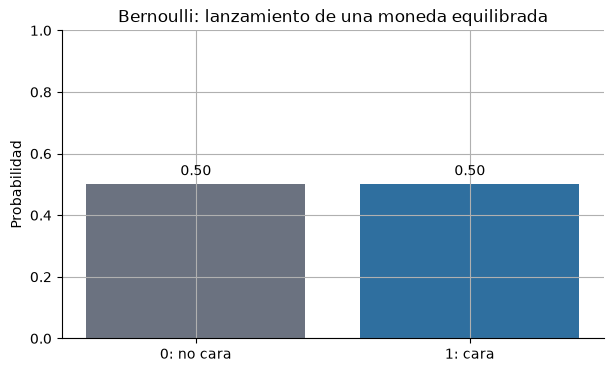

E[X] = 0.50
Var(X) = 0.25


In [ ]:
# Puedes cambiar la probabilidad p
p = 0.5 # Probabilidad
xs = [0, 1]
ps = [bernoulli_pmf(x, p) for x in xs]

fig, ax = plt.subplots()
ax.bar(["0: no cara", "1: cara"], ps, color=[GRIS, AZUL])
ax.set_ylim(0, 1)
ax.set_ylabel("Probabilidad")
ax.set_title("Bernoulli: lanzamiento de una moneda equilibrada")
for i, value in enumerate(ps):
    ax.text(i, value + 0.03, f"{value:.2f}", ha="center")
plt.show()

print(f"E[X] = {p:.2f}")
print(f"Var(X) = {p * (1 - p):.2f}")

## Binomial

Se usa cuando se repite el mismo ensayo Bernoulli $n$ veces, con independencia y la misma probabilidad de éxito $p$.

Si $Y$ cuenta cuántos éxitos ocurren:

$$
Y\sim \operatorname{Bin}(n,p)
$$

$$
P(Y=k)=\binom nk p^k(1-p)^{n-k}
$$

La fórmula junta tres ideas:

- $\binom nk$ cuenta las formas de ubicar $k$ éxitos.
- $p^k$ representa los éxitos.
- $(1-p)^{n-k}$ representa los fracasos.

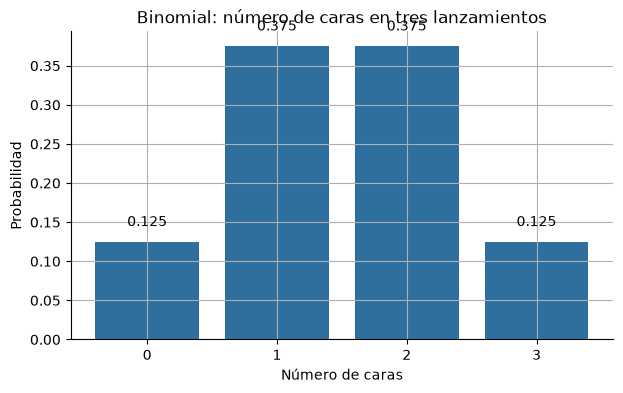

P(Y = 2) = 0.375


In [ ]:
# Tres lanzamientos de moneda. Puedes modificar la probabilidad, el número de lanzamientos,
# y el número de éxitos
n = 3 # Número de lanzamientos
p = 0.5 # Probabilidad de éxito
ks = list(range(n + 1)) # Número de éxitos
probs = [binomial_pmf(k, n, p) for k in ks]

fig, ax = plt.subplots()
ax.bar(ks, probs, color=AZUL)
ax.set_xticks(ks)
ax.set_xlabel("Número de caras")
ax.set_ylabel("Probabilidad")
ax.set_title("Binomial: número de caras en tres lanzamientos")
for k, value in zip(ks, probs):
    ax.text(k, value + 0.02, f"{value:.3f}", ha="center")
plt.show()

print(f"P(Y = 2) = {binomial_pmf(2, n, p):.3f}")

## Binomial en confiabilidad: contenedores

Ejemplo de la presentación: diez contenedores están operativos con probabilidad $p=0.92$, de forma independiente. La plataforma necesita al menos nueve operativos.

Sea $Y$ el número de contenedores operativos.

$$
Y\sim \operatorname{Bin}(10,0.92)
$$

La probabilidad buscada es:

$$
P(Y\ge 9)=P(Y=9)+P(Y=10)
$$

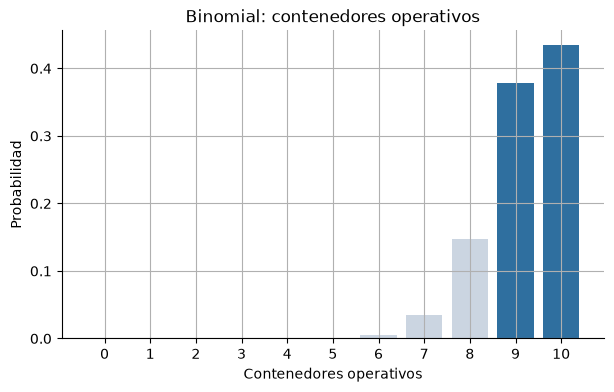

P(Y >= 9) = 0.8121


In [7]:
n = 10
p = 0.92
ks = list(range(n + 1))
probs = [binomial_pmf(k, n, p) for k in ks]
prob_at_least_9 = sum(probs[9:])

colors = [AZUL if k >= 9 else "#cbd5e1" for k in ks]
fig, ax = plt.subplots()
ax.bar(ks, probs, color=colors)
ax.set_xticks(ks)
ax.set_xlabel("Contenedores operativos")
ax.set_ylabel("Probabilidad")
ax.set_title("Binomial: contenedores operativos")
plt.show()

print(f"P(Y >= 9) = {prob_at_least_9:.4f}")

## Geométrica

Se usa cuando se repiten intentos independientes hasta observar el primer éxito.

Ejemplo de la presentación: un paquete se recibe correctamente con probabilidad $p=0.8$ en cada intento. Se pregunta por la probabilidad de lograrlo recién en el tercer intento.

Si $K$ cuenta el intento donde ocurre el primer éxito:

$$
P(K=k)=(1-p)^{k-1}p,\qquad k=1,2,\ldots
$$

- $(1-p)^{k-1}$ representa los fracasos previos.
- $p$ representa el éxito final.
- $E[K]=1/p$ es el número medio de intentos.

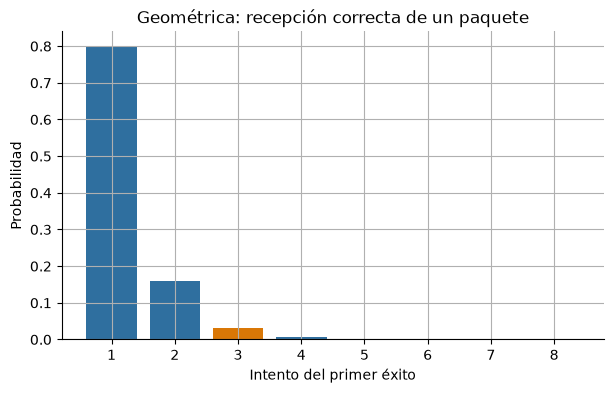

P(K = 3) = 0.032
E[K] = 1.25 intentos


In [8]:
p = 0.8
ks = list(range(1, 9))
probs = [geometric_pmf(k, p) for k in ks]

colors = [NARANJO if k == 3 else AZUL for k in ks]
fig, ax = plt.subplots()
ax.bar(ks, probs, color=colors)
ax.set_xticks(ks)
ax.set_xlabel("Intento del primer éxito")
ax.set_ylabel("Probabilidad")
ax.set_title("Geométrica: recepción correcta de un paquete")
plt.show()

print(f"P(K = 3) = {geometric_pmf(3, p):.3f}")
print(f"E[K] = {1 / p:.2f} intentos")

## Poisson

Se usa para contar eventos en un intervalo cuando la tasa puede considerarse constante.

Ejemplo de la presentación: una red registra en promedio $\nu=2$ fallas por semana. Se pregunta por la probabilidad de observar exactamente tres fallas en una semana.

$$
P(N(t)=k)=\frac{(\nu t)^k e^{-\nu t}}{k!}
$$

Donde:

- $\nu$ es la tasa media de eventos.
- $t$ es la duración del intervalo.
- $\nu t$ es el conteo medio esperado.
- $k$ es el conteo observado.

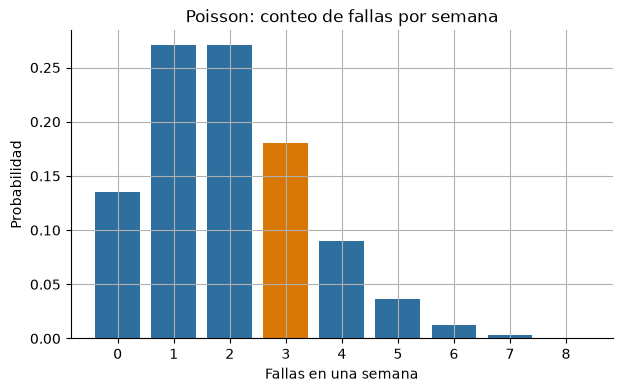

P(N(1) = 3) = 0.1804


In [9]:
nu = 2
t = 1
mean = nu * t
ks = list(range(0, 9))
probs = [poisson_pmf(k, mean) for k in ks]

colors = [NARANJO if k == 3 else AZUL for k in ks]
fig, ax = plt.subplots()
ax.bar(ks, probs, color=colors)
ax.set_xticks(ks)
ax.set_xlabel("Fallas en una semana")
ax.set_ylabel("Probabilidad")
ax.set_title("Poisson: conteo de fallas por semana")
plt.show()

print(f"P(N(1) = 3) = {poisson_pmf(3, mean):.4f}")

## Exponencial

Se usa para modelar el tiempo hasta el próximo evento cuando la tasa de ocurrencia es constante.

Ejemplo de la presentación: un equipo tiene tasa de falla $\lambda=0.01\ \mathrm h^{-1}$. Se pregunta por la probabilidad de sobrevivir más de $150\ \mathrm h$.

$$
f_T(t)=\lambda e^{-\lambda t},\qquad t\ge0
$$

$$
P(T>t)=e^{-\lambda t}
$$

Donde $\lambda$ es la tasa de falla y $E[T]=1/\lambda$ es el tiempo medio hasta el evento.

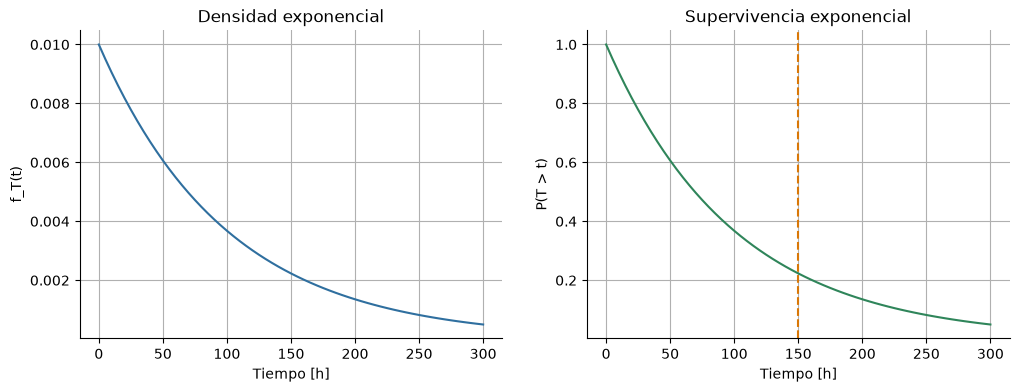

E[T] = 100.0 h
P(T > 150 h) = 0.2231


In [10]:
rate = 0.01
times = list(range(0, 301, 5))
density = [exponential_pdf(t, rate) for t in times]
survival = [exponential_survival(t, rate) for t in times]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(times, density, color=AZUL)
axes[0].set_title("Densidad exponencial")
axes[0].set_xlabel("Tiempo [h]")
axes[0].set_ylabel("f_T(t)")

axes[1].plot(times, survival, color=VERDE)
axes[1].axvline(150, color=NARANJO, linestyle="--")
axes[1].set_title("Supervivencia exponencial")
axes[1].set_xlabel("Tiempo [h]")
axes[1].set_ylabel("P(T > t)")
plt.show()

print(f"E[T] = {1 / rate:.1f} h")
print(f"P(T > 150 h) = {exponential_survival(150, rate):.4f}")

## Weibull

Se usa cuando el riesgo de falla cambia con la edad del componente.

Ejemplo de la presentación: una fuente de poder muestra desgaste. Se modela con $\beta=2$ y escala $\eta=1000\ \mathrm h$. La pregunta es la probabilidad de que siga funcionando después de $500\ \mathrm h$.

$$
R(t)=P(T>t)=e^{-(t/\eta)^\beta}
$$

$$
h(t)=\frac{\beta}{\eta}\left(\frac{t}{\eta}\right)^{\beta-1}
$$

Donde $\beta$ controla la forma del riesgo y $\eta$ escala el tiempo.

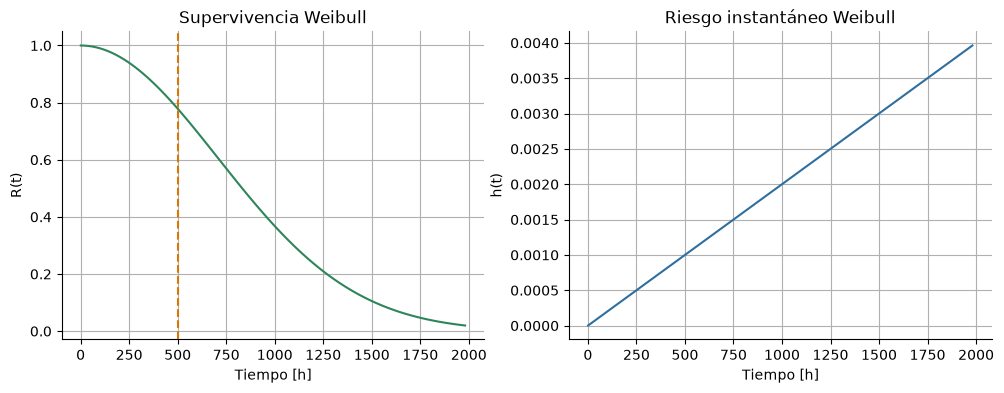

R(500) = 0.7788


In [11]:
beta = 2
eta = 1000
times = list(range(1, 2001, 20))
survival = [weibull_survival(t, beta, eta) for t in times]
hazard = [weibull_hazard(t, beta, eta) for t in times]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(times, survival, color=VERDE)
axes[0].axvline(500, color=NARANJO, linestyle="--")
axes[0].set_title("Supervivencia Weibull")
axes[0].set_xlabel("Tiempo [h]")
axes[0].set_ylabel("R(t)")

axes[1].plot(times, hazard, color=AZUL)
axes[1].set_title("Riesgo instantáneo Weibull")
axes[1].set_xlabel("Tiempo [h]")
axes[1].set_ylabel("h(t)")
plt.show()

print(f"R(500) = {weibull_survival(500, beta, eta):.4f}")

## Comparación visual de formas Weibull

La forma $\beta$ cambia la interpretación física del riesgo.

- $0<\beta<1$: riesgo decreciente, típico de fallas tempranas.
- $\beta=1$: riesgo constante, coincide con el caso exponencial.
- $\beta>1$: riesgo creciente, típico de desgaste.

In [ ]:
eta = 1000
betas = [0.7, 1.0, 2.0]
times = list(range(1, 2001, 20))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for beta in betas:
    axes[0].plot(times, [weibull_survival(t, beta, eta) for t in times], label=f"beta={beta}")
    axes[1].plot(times, [weibull_hazard(t, beta, eta) for t in times], label=f"beta={beta}")

axes[0].set_title("Supervivencia para distintas formas")
axes[0].set_xlabel("Tiempo [h]")
axes[0].set_ylabel("R(t)")
axes[0].legend()

axes[1].set_title("Riesgo para distintas formas")
axes[1].set_xlabel("Tiempo [h]")
axes[1].set_ylabel("h(t)")
axes[1].legend()
plt.show()

## Resumen de selección

| Situación | Distribución útil |
|---|---|
| Un resultado sí o no | Bernoulli |
| Número de éxitos en $n$ ensayos | Binomial |
| Intentos hasta el primer éxito | Geométrica |
| Conteo de eventos en un intervalo | Poisson |
| Tiempo hasta falla con tasa constante | Exponencial |
| Tiempo hasta falla con riesgo variable | Weibull |

Antes de calcular, conviene declarar la variable, la distribución, los parámetros y el supuesto principal.